In [1]:
from pathlib import Path
import json

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

RESULTS = PROJECT_ROOT / "results" / "reports"

MODELS = PROJECT_ROOT / "models"

In [3]:
with open(RESULTS/"cnn_metrics.json") as file:

    cnn = json.load(file)

cnn

{'Accuracy': 0.9915555555555555,
 'Precision': 0.9917091351388618,
 'Recall': 0.9915555555555555,
 'F1 Score': 0.9915733148118986,
 'Prediction Time': 35.94913697242737,
 'Inference Time': 0.00399434855249193}

In [4]:
with open(MODELS/"random_forest_metadata.json") as file:

    rf = json.load(file)

rf

{'accuracy': 0.9601666666666666,
 'precision': 0.9602540517817445,
 'recall': 0.9601666666666666,
 'f1': 0.9601381058220961,
 'training_time': 84.99372386932373,
 'prediction_time': 0.8207108974456787,
 'threshold': 0.75}

In [5]:
with open(MODELS/"svm_metadata.json") as file:

    svm = json.load(file)

svm

{'accuracy': 0.9561111111111111,
 'precision': 0.9561344074305267,
 'recall': 0.9561111111111111,
 'f1': 0.9560289693777777,
 'training_time': 543.279892206192,
 'prediction_time': 43.65683054924011,
 'unknown_threshold': 0.75}

In [13]:
def metric_value(metrics, *keys, default=np.nan):
    for key in keys:
        if key in metrics:
            return metrics[key]
    return default

cnn_training_time = metric_value(cnn, "Training Time", "training_time")
cnn_prediction_time = metric_value(cnn, "Prediction Time", "prediction_time", "Inference Time")

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Training Time",

        "Prediction Time"

    ],

    "Random Forest":[

        rf["accuracy"],

        rf["precision"],

        rf["recall"],

        rf["f1"],

        rf["training_time"],

        rf["prediction_time"]

    ],

    "SVM":[

        svm["accuracy"],

        svm["precision"],

        svm["recall"],

        svm["f1"],

        svm["training_time"],

        svm["prediction_time"]

    ],

    "CNN":[

        cnn["Accuracy"],

        cnn["Precision"],

        cnn["Recall"],

        cnn["F1 Score"],

        cnn_training_time,

        cnn_prediction_time

    ]

})

comparison

,Metric,Random Forest,SVM,CNN
0,Accuracy,0.960167,0.956111,0.991556
1,Precision,0.960254,0.956134,0.991709
2,Recall,0.960167,0.956111,0.991556
3,F1 Score,0.960138,0.956029,0.991573
4,Training Time,84.993724,543.279892,NaN
5,Prediction Time,0.820711,43.656831,35.949137


In [14]:
comparison.to_csv(

    RESULTS/"model_comparison.csv",

    index=False

)

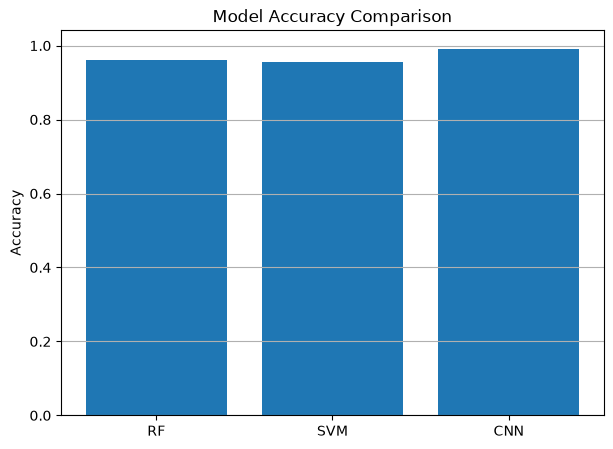

In [15]:
plt.figure(figsize=(7,5))

plt.bar(

    ["RF","SVM","CNN"],

    [

        rf["accuracy"],

        svm["accuracy"],

        cnn["Accuracy"]

    ]

)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.grid(axis="y")

plt.show()

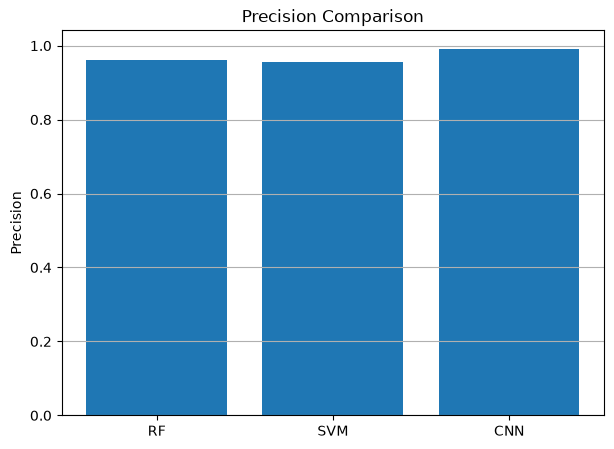

In [16]:
plt.figure(figsize=(7,5))

plt.bar(

    ["RF","SVM","CNN"],

    [

        rf["precision"],

        svm["precision"],

        cnn["Precision"]

    ]

)

plt.ylabel("Precision")

plt.title("Precision Comparison")

plt.grid(axis="y")

plt.show()

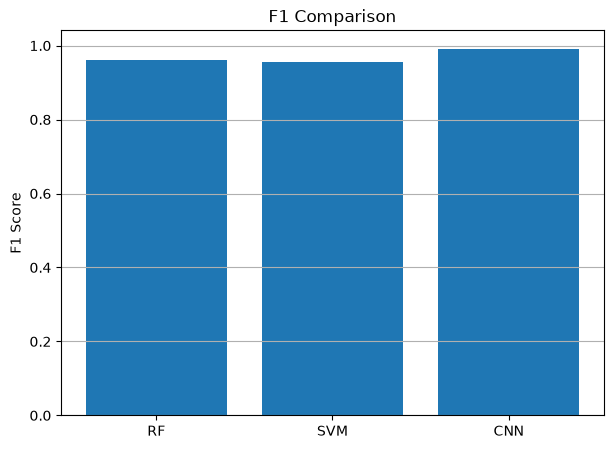

In [17]:
plt.figure(figsize=(7,5))

plt.bar(

    ["RF","SVM","CNN"],

    [

        rf["f1"],

        svm["f1"],

        cnn["F1 Score"]

    ]

)

plt.ylabel("F1 Score")

plt.title("F1 Comparison")

plt.grid(axis="y")

plt.show()

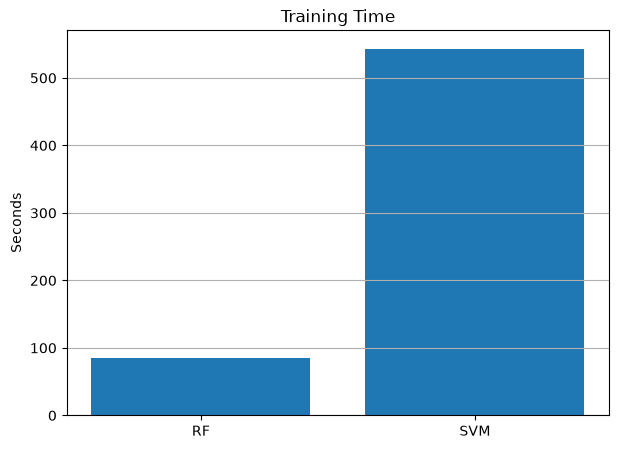

In [19]:
plt.figure(figsize=(7,5))

plt.bar(

    ["RF","SVM","CNN"],

    [

        rf["training_time"],

        svm["training_time"],

        cnn_training_time

    ]

)

plt.ylabel("Seconds")

plt.title("Training Time")

plt.grid(axis="y")

plt.show()

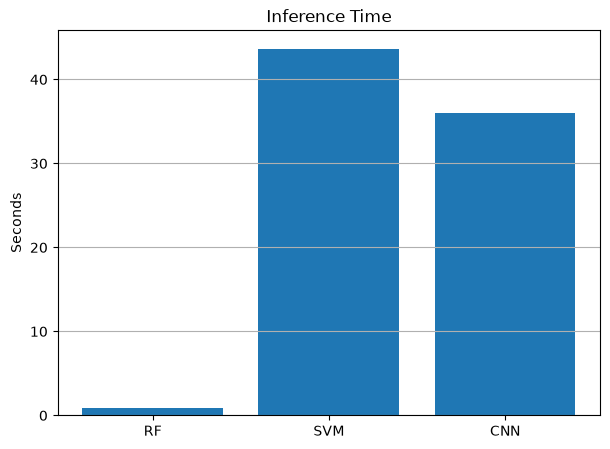

In [20]:
plt.figure(figsize=(7,5))

plt.bar(

    ["RF","SVM","CNN"],

    [

        rf["prediction_time"],

        svm["prediction_time"],

        cnn["Prediction Time"]

    ]

)

plt.ylabel("Seconds")

plt.title("Inference Time")

plt.grid(axis="y")

plt.show()

In [21]:
rf_size = (MODELS/"random_forest.pkl").stat().st_size/(1024**2)

svm_size = (MODELS/"svm.pkl").stat().st_size/(1024**2)

cnn_size = (MODELS/"cnn_best.pth").stat().st_size/(1024**2)

sizes = pd.DataFrame({

    "Model":[

        "Random Forest",

        "SVM",

        "CNN"

    ],

    "Size(MB)":[

        rf_size,

        svm_size,

        cnn_size

    ]

})

sizes

,Model,Size(MB)
0,Random Forest,225.861176
1,SVM,2.936393
2,CNN,5.452070


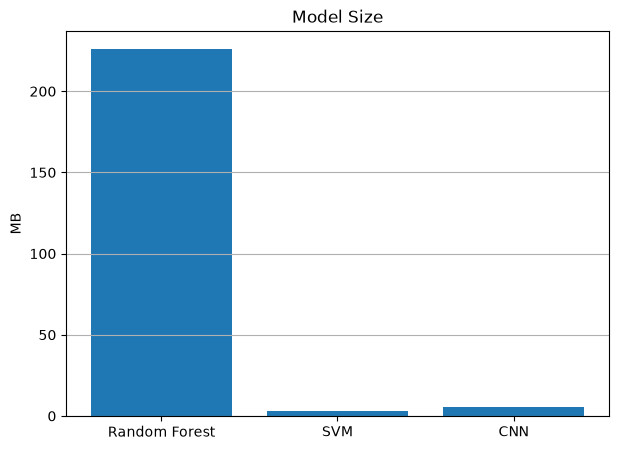

In [22]:
plt.figure(figsize=(7,5))

plt.bar(

    sizes["Model"],

    sizes["Size(MB)"]

)

plt.ylabel("MB")

plt.title("Model Size")

plt.grid(axis="y")

plt.show()

In [23]:
rf_class = pd.read_csv(

    RESULTS/"per_class_accuracy.csv"

)

svm_class = pd.read_csv(

    RESULTS/"svm_per_class_accuracy.csv"

)

cnn_class = pd.read_csv(

    RESULTS/"cnn_per_class_accuracy.csv"

)

In [24]:
comparison_class = pd.DataFrame({

    "Class":rf_class["Modulation"],

    "RF":rf_class["Accuracy"],

    "SVM":svm_class["Accuracy"],

    "CNN":cnn_class["Accuracy"]

})

comparison_class

,Class,RF,SVM,CNN
0,8PSK,0.8825,0.8565,0.974
1,AM-DSB,0.9995,1.0000,0.999
2,AM-SSB,1.0000,0.9960,1.000
3,BPSK,0.9830,0.9885,0.989
4,CPFSK,0.9535,0.9665,1.000
5,GFSK,0.9825,0.9795,1.000
6,PAM4,0.9755,0.9810,0.994
7,QAM64,0.9640,0.9705,0.987
8,QPSK,0.9010,0.8665,0.981


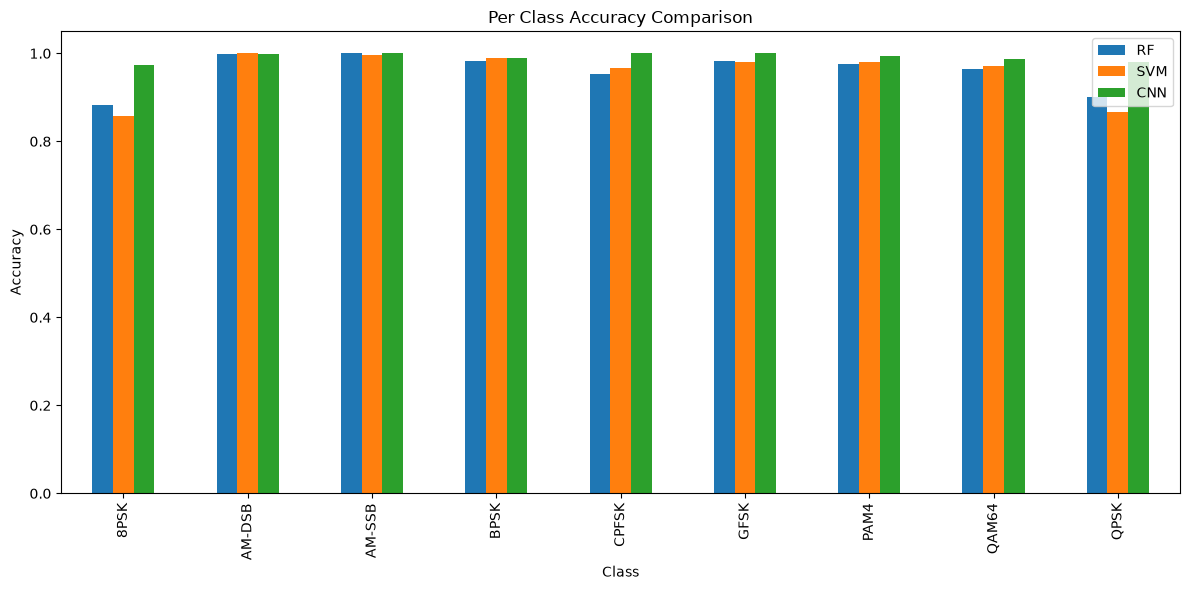

In [25]:
comparison_class.plot(

    x="Class",

    figsize=(12,6),

    kind="bar"

)

plt.ylabel("Accuracy")

plt.title("Per Class Accuracy Comparison")

plt.tight_layout()

plt.show()

In [26]:
print("="*80)

print("PROJECT PERFORMANCE SUMMARY")

print("="*80)

print()

print(comparison)

print()

print(sizes)

print()

print("Best Accuracy Model :",

      comparison.iloc[0,1:].idxmax())

print()

print("Smallest Model :",

      sizes.loc[sizes["Size(MB)"].idxmin(),"Model"])

print()

print("Fastest Inference :",

      comparison.iloc[5,1:].idxmin())

print("="*80)

PROJECT PERFORMANCE SUMMARY

            Metric  Random Forest         SVM        CNN
0         Accuracy       0.960167    0.956111   0.991556
1        Precision       0.960254    0.956134   0.991709
2           Recall       0.960167    0.956111   0.991556
3         F1 Score       0.960138    0.956029   0.991573
4    Training Time      84.993724  543.279892        NaN
5  Prediction Time       0.820711   43.656831  35.949137

           Model    Size(MB)
0  Random Forest  225.861176
1            SVM    2.936393
2            CNN    5.452070

Best Accuracy Model : CNN

Smallest Model : SVM

Fastest Inference : Random Forest


In [30]:
# ==========================================================
# Load Accuracy vs SNR Files
# ==========================================================

rf_snr = pd.read_csv(
    RESULTS / "rf_accuracy_vs_snr.csv"
)

svm_snr = pd.read_csv(
    RESULTS / "svm_accuracy_vs_snr.csv"
)

cnn_snr = pd.read_csv(
    RESULTS / "cnn_accuracy_vs_snr.csv"
)

# Normalize column name for CNN to match others
if "SNR" in cnn_snr.columns and "OriginalSNR" not in cnn_snr.columns:
    cnn_snr = cnn_snr.rename(columns={"SNR": "OriginalSNR"})

# ==========================================================
# Prepare common SNR axis
# ==========================================================

rf_snr["OriginalSNR"] = rf_snr["OriginalSNR"].astype(float)
svm_snr["OriginalSNR"] = svm_snr["OriginalSNR"].astype(float)
cnn_snr["OriginalSNR"] = cnn_snr["OriginalSNR"].astype(float)

rf_snr = rf_snr.sort_values("OriginalSNR").reset_index(drop=True)
svm_snr = svm_snr.sort_values("OriginalSNR").reset_index(drop=True)
cnn_snr = cnn_snr.sort_values("OriginalSNR").reset_index(drop=True)

# If SVM is on a different numeric scale, map it onto the RF/CNN SNR range first.
svm_min = svm_snr["OriginalSNR"].min()
svm_max = svm_snr["OriginalSNR"].max()
rf_min = rf_snr["OriginalSNR"].min()
rf_max = rf_snr["OriginalSNR"].max()

if svm_max > svm_min and (svm_min < rf_min or svm_max > rf_max):
    svm_snr = svm_snr.copy()
    svm_snr["OriginalSNR"] = (
        (svm_snr["OriginalSNR"] - svm_min) / (svm_max - svm_min) * (rf_max - rf_min)
        + rf_min
    )

# Collapse any duplicate SNR bins created by mapping/rounding behavior.
svm_snr = svm_snr.groupby("OriginalSNR", as_index=False)["Accuracy"].mean()
cnn_snr = cnn_snr.groupby("OriginalSNR", as_index=False)["Accuracy"].mean()

# ==========================================================
# Align all models to the RF SNR axis
# ==========================================================

comparison_snr = pd.DataFrame({
    "OriginalSNR": rf_snr["OriginalSNR"],
    "Accuracy_RF": rf_snr["Accuracy"],
    "Accuracy_SVM": np.interp(
        rf_snr["OriginalSNR"],
        svm_snr["OriginalSNR"],
        svm_snr["Accuracy"]
    ),
    "Accuracy_CNN": np.interp(
        rf_snr["OriginalSNR"],
        cnn_snr["OriginalSNR"],
        cnn_snr["Accuracy"]
    ),
})

comparison_snr

,OriginalSNR,Accuracy_RF,Accuracy_SVM,Accuracy_CNN
0,0.0,0.966000,0.860875,0.975890
1,2.0,0.959000,0.944291,0.993151
2,4.0,0.961000,0.962410,0.995455
3,6.0,0.958667,0.970670,0.995392
4,8.0,0.960000,0.970457,0.992081
5,8.0,0.960000,0.974596,0.992081
6,10.0,0.966000,0.976306,0.995449
7,12.0,0.957667,0.966910,0.993776
8,14.0,0.961000,0.963149,0.988397
9,16.0,0.962000,0.969239,0.992222


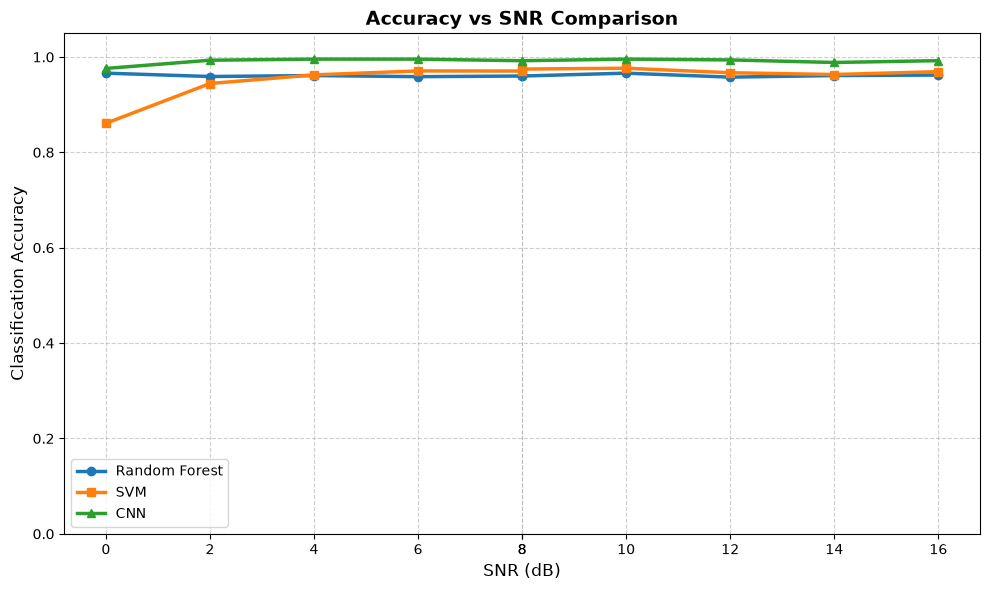

In [31]:
plt.figure(figsize=(10,6))

plt.plot(
    comparison_snr["OriginalSNR"],
    comparison_snr["Accuracy_RF"],
    marker="o",
    linewidth=2.5,
    label="Random Forest"
)

plt.plot(
    comparison_snr["OriginalSNR"],
    comparison_snr["Accuracy_SVM"],
    marker="s",
    linewidth=2.5,
    label="SVM"
)

plt.plot(
    comparison_snr["OriginalSNR"],
    comparison_snr["Accuracy_CNN"],
    marker="^",
    linewidth=2.5,
    label="CNN"
)

plt.xlabel("SNR (dB)", fontsize=12)

plt.ylabel("Classification Accuracy", fontsize=12)

plt.title(
    "Accuracy vs SNR Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(comparison_snr["OriginalSNR"])

plt.ylim(0, 1.05)

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()

plt.tight_layout()

plt.show()

In [32]:
comparison_snr.to_csv(

    RESULTS / "accuracy_vs_snr_comparison.csv",

    index=False

)

print("="*60)

print("Saved : accuracy_vs_snr_comparison.csv")

print("="*60)

Saved : accuracy_vs_snr_comparison.csv


In [33]:
best_model = []

for _, row in comparison_snr.iterrows():

    scores = {
        "Random Forest": row["Accuracy_RF"],
        "SVM": row["Accuracy_SVM"],
        "CNN": row["Accuracy_CNN"]
    }

    best = max(scores, key=scores.get)

    best_model.append(best)

snr_summary = pd.DataFrame({

    "OriginalSNR": comparison_snr["OriginalSNR"],

    "Best Model": best_model

})

snr_summary

,OriginalSNR,Best Model
0,0.0,CNN
1,2.0,CNN
2,4.0,CNN
3,6.0,CNN
4,8.0,CNN
5,8.0,CNN
6,10.0,CNN
7,12.0,CNN
8,14.0,CNN
9,16.0,CNN


In [34]:
snr_summary.to_csv(

    RESULTS / "best_model_per_snr.csv",

    index=False

)

print("="*60)

print("Saved : best_model_per_snr.csv")

print("="*60)

Saved : best_model_per_snr.csv
